# Per author statistics 

We have identified some issues with name disambiguation, so we are running some descriptive stats on the authors. first look at the full set of all SFU authors, and then also my deduplicated lists to see what's going on. 

Some key statistics to check are: 
* number of alternate names
* number of affiliated institutions 
* number of publications
* publications per year(?) 
* time span of published works(?)


In [14]:
# import libraries 

import pandas as pd
import numpy as np
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict
import matplotlib.pyplot as plt

In [3]:
sfu_all = pd.read_csv('sfu_all_authors.csv')

sfu_all

,id,orcid,display_name,display_name_alternatives,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,topic_share,x_concepts,counts_by_year,works_api_url,updated_date,created_date
0,https://openalex.org/A5114378471,https://orcid.org/0000-0002-0721-8331,B. Liu,"['B. Liu', 'B L Liu', 'B Liu', 'B X Liu', 'B. ...",2266,110309,"{'2yr_mean_citedness': 6.5344311377245505, 'h_...",{'openalex': 'https://openalex.org/A5114378471...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I126520041', 'ro...","[{'id': 'https://openalex.org/T10048', 'displa...","[{'id': 'https://openalex.org/T10527', 'displa...","[{'id': '10138342', 'wikidata': 'https://www.w...","[{'year': 1965, 'works_count': 1, 'oa_works_co...",https://api.openalex.org/works?filter=author.i...,2025-11-02T23:13:26.583910,2016-06-24
1,https://openalex.org/A5019316470,https://orcid.org/0000-0002-7223-2965,M. C. Vetterli,"['M. C. Vetterli', 'A. Vgenopoulos', 'D. Ventu...",1859,105597,"{'2yr_mean_citedness': 5.203389830508475, 'h_i...",{'openalex': 'https://openalex.org/A5019316470...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I1304378839', 'r...","[{'id': 'https://openalex.org/T10048', 'displa...","[{'id': 'https://openalex.org/T10527', 'displa...","[{'id': '105702510', 'wikidata': 'https://www....","[{'year': 1983, 'works_count': 1, 'oa_works_co...",https://api.openalex.org/works?filter=author.i...,2025-11-02T23:13:26.583910,2016-06-24
2,https://openalex.org/A5077377484,https://orcid.org/0000-0003-0027-7969,J. Llorente Merino,"['J. Llorente Merino', 'J Llorente Merino', 'J...",1681,92792,"{'2yr_mean_citedness': 5.543181818181818, 'h_i...",{'openalex': 'https://openalex.org/A5077377484...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...","[{'id': 'https://openalex.org/T10048', 'displa...","[{'id': 'https://openalex.org/T10527', 'displa...","[{'id': '109214941', 'wikidata': 'https://www....","[{'year': 2008, 'works_count': 1, 'oa_works_co...",https://api.openalex.org/works?filter=author.i...,2025-11-02T23:13:26.583910,2016-06-24
3,https://openalex.org/A5039614567,https://orcid.org/0000-0002-7807-7484,M. Danninger,"['M. Danninger', 'Danninger, M.', 'Danninger, ...",1430,62257,"{'2yr_mean_citedness': 5.130434782608695, 'h_i...",{'openalex': 'https://openalex.org/A5039614567...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...","[{'id': 'https://openalex.org/T10048', 'displa...","[{'id': 'https://openalex.org/T10527', 'displa...","[{'id': '109214941', 'wikidata': 'https://www....","[{'year': 2007, 'works_count': 2, 'oa_works_co...",https://api.openalex.org/works?filter=author.i...,2025-11-01T23:18:31.786418,2016-06-24
4,https://openalex.org/A5100397026,https://orcid.org/0000-0003-1991-119X,Hao Zhang,"['Hao Zhang', 'H. Zhang', 'HAO ZHANG', 'HONG-J...",1370,63147,"{'2yr_mean_citedness': 2.3508771929824563, 'h_...",{'openalex': 'https://openalex.org/A5100397026...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I102345215', 'ro...","[{'id': 'https://openalex.org/T10627', 'displa...","[{'id': 'https://openalex.org/T10719', 'displa...","[{'id': '100082104', 'wikidata': 'https://www....","[{'year': 1993, 'works_count': 2, 'oa_works_co...",https://api.openalex.org/works?filter=author.i...,2025-11-02T23:13:26.583910,2016-06-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9963,https://openalex.org/A5119544262,NaN,Dominic Jaworiski,['Dominic Jaworiski'],1,0,"{'2yr_mean_citedness': 0.0, 'h_index': 0, 'i10...",{'openalex': 'https://openalex.org/A5119544262...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...","[{'id': 'https://openalex.org/T10783', 'displa...","[{'id': 'https://openalex.org/T10719', 'displa...","[{'id': '15744967', 'wikidata': 'https://www.w...","[{'year': 2025, 'wo

In [4]:
sfu_all.columns

Index(['id', 'orcid', 'display_name', 'display_name_alternatives',
       'works_count', 'cited_by_count', 'summary_stats', 'ids', 'affiliations',
       'last_known_institutions', 'topics', 'topic_share', 'x_concepts',
       'counts_by_year', 'works_api_url', 'updated_date', 'created_date'],
      dtype='object')

In [9]:
print(ast.literal_eval(sfu_all['display_name_alternatives'][0]))

len(ast.literal_eval(sfu_all['display_name_alternatives'][0]))

['B. Liu', 'B L Liu', 'B Liu', 'B X Liu', 'B. L Liu', 'B. L. Liu', 'B. X. Liu', 'B.L Liu', 'B.L. Liu', 'B.X Liu']


10

In [13]:
sfu_all['num_names'] = sfu_all['display_name_alternatives'].apply(lambda x: len(ast.literal_eval(x)))
sfu_all['num_institutions'] = sfu_all['affiliations'].apply(lambda x: len(ast.literal_eval(x)))

sfu_all['num_institutions'].unique()

array([ 69,  51,  32,  39, 262, 147, 141,  20, 169, 309, 202,  22,  37,
       159,  90,   3, 168,  74,  33,  81,  63,  46,  25,  24, 139,  36,
        55,  38,  56,  41,  45,   8,  11,  23,  76,  16,  13,  14,  27,
        18,  75,  21,  19, 101,  42,  26,  17,   7,  29,   4,  10,   6,
        31,  15,   5,  47,  34,  68,   9,  49, 108,  12,  58,  71,  57,
        43,  86,   1,  28,  70,  73,  40,  30,  52,   2,  61,  35,  62])

In [20]:
sfu_all['num_names'].describe()

count    9968.000000
mean        2.224719
std         2.075011
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: num_names, dtype: float64

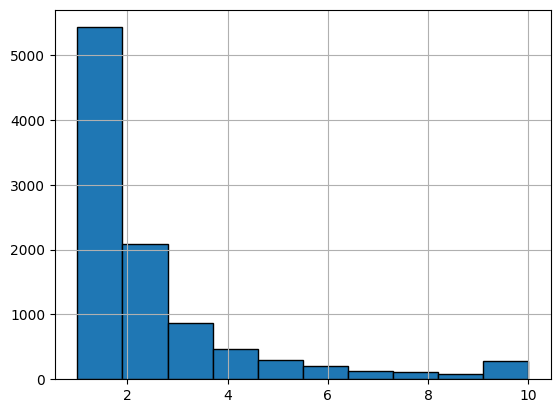

In [15]:
sfu_all['num_names'].hist(edgecolor='black')
plt.show()

In [21]:
sfu_all['num_institutions'].describe()

count    9968.000000
mean        3.336477
std         8.400167
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       309.000000
Name: num_institutions, dtype: float64

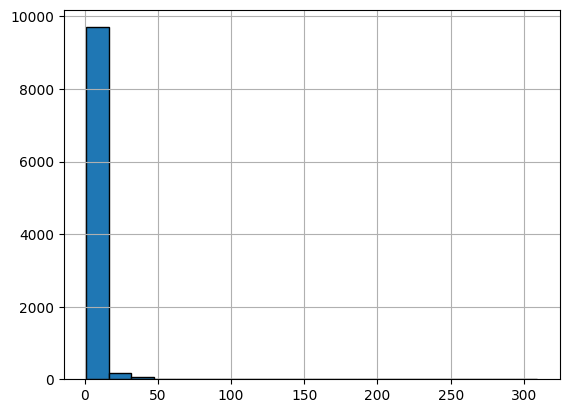

In [28]:
sfu_all['num_institutions'].hist(bins=20, edgecolor='black')
plt.show()

In [27]:
sfu_all['num_institutions'].unique()

array([ 69,  51,  32,  39, 262, 147, 141,  20, 169, 309, 202,  22,  37,
       159,  90,   3, 168,  74,  33,  81,  63,  46,  25,  24, 139,  36,
        55,  38,  56,  41,  45,   8,  11,  23,  76,  16,  13,  14,  27,
        18,  75,  21,  19, 101,  42,  26,  17,   7,  29,   4,  10,   6,
        31,  15,   5,  47,  34,  68,   9,  49, 108,  12,  58,  71,  57,
        43,  86,   1,  28,  70,  73,  40,  30,  52,   2,  61,  35,  62])